# Phase 1: Document Vectorization (LangChain Edition)

This notebook demonstrates the first stage of the RAG pipeline using LangChain abstractions: **Ingestion and Storage**.

We will cover:
1. **Extraction**: Reading text from a PDF into LangChain `Document` objects.
2. **Chunking**: Splitting `Document`s into manageable segments.
3. **Embedding**: Converting text into semantic vectors using `HuggingFaceEmbeddings`.
4. **Indexing**: Saving segments to a local ChromaDB store via LangChain.

In [1]:
import os
import sys

# Add the src directory to the python path so we can import our modules
sys.path.append(os.path.abspath('../src'))

from ingest.parser import extract_text_from_pdf
from ingest.chunker import chunk_documents
from rag.retriever import VectorRetriever

print("Modules loaded successfully.")

Modules loaded successfully.


## 1. Text Extraction

We'll use LangChain's `PDFPlumberLoader` to extract raw text from a sample PDF.

> **Note**: We use specific `x_tolerance` settings to handle complex academic layouts and ensure words don't get stuck together.

In [2]:
pdf_path = "../data/raw/sample.pdf"

if not os.path.exists(pdf_path):
    print(f"Error: {pdf_path} not found. Please ensure a sample PDF exists in data/raw/")
else:
    documents = extract_text_from_pdf(pdf_path)
    print(f"Extracted {len(documents)} pages from the PDF.")
    print("\n--- Sample Text (First 1000 chars of Page 1) ---")
    # We print the first 1000 chars to verify spacing and readability
    print(documents[0].page_content[:1000])

Extracted 12 pages from the PDF.

--- Sample Text (First 1000 chars of Page 1) ---
1
Capturing Monetarily Exploitable Vulnerability in
Smart Contracts via Auditor Knowledge-Learning
Fuzzing
1 1 2 3 1
Bowen Cai , Weiheng Bai , Hangyun Tang , Youshui Lu , Kangjie Lu
1 2 3
University of Minnesota - Twin Cities, Fudan University, Xi’an Jiaotong University
{cai000254, bai00093}@umn.edu, {23110240090}@m.fudan.edu.cn,
{yolu6176}@uni.sydney.edu.au, {kjlu}@umn.edu
Abstract—Smart contracts have extended blockchain functional- Automated fuzzing tools have significantly advanced smart
ity beyond simple transactions, powering complex applications like contract security by mitigating traditional vulnerabilities such as
decentralized finance (DeFi). However, this complexity introduces
serious security challenges, including price manipulation and
reentrancy, under/overflow errors, and unsafe delegate calls [9]–
inflation attacks. Despite the development of various security
[12]. Early fuzzing techniqu

## 2. Text Chunking

Raw text is too long for LLMs to process efficiently. We split our LangChain `Document`s into smaller overlapping chunks.

In [3]:
chunk_size = 500
chunk_overlap = 100
chunks = chunk_documents(documents, chunk_size=chunk_size, chunk_overlap=chunk_overlap)
print(f"Split documents into {len(chunks)} chunks.")

if chunks:
    print("\n--- Chunk 1 ---")
    print(chunks[0].page_content)

    print("\n--- Chunk 2 ---")
    print(chunks[1].page_content)

Split documents into 188 chunks.

--- Chunk 1 ---
1
Capturing Monetarily Exploitable Vulnerability in
Smart Contracts via Auditor Knowledge-Learning
Fuzzing
1 1 2 3 1
Bowen Cai , Weiheng Bai , Hangyun Tang , Youshui Lu , Kangjie Lu
1 2 3
University of Minnesota - Twin Cities, Fudan University, Xi’an Jiaotong University
{cai000254, bai00093}@umn.edu, {23110240090}@m.fudan.edu.cn,
{yolu6176}@uni.sydney.edu.au, {kjlu}@umn.edu
Abstract—Smart contracts have extended blockchain functional- Automated fuzzing tools have significantly advanced smart

--- Chunk 2 ---
ity beyond simple transactions, powering complex applications like contract security by mitigating traditional vulnerabilities such as
decentralized finance (DeFi). However, this complexity introduces
reentrancy, under/overflow errors, and unsafe delegate calls [9]–
serious security challenges, including price manipulation and
[12]. Early fuzzing techniques used random input generators,
inflation attacks. Despite the development of 

## 3. Vector Storage (LangChain Chroma)

Now we convert these chunks into embeddings using a local `HuggingFaceEmbeddings` model and save them to our local Chroma vector store via LangChain.

In [4]:
retriever = VectorRetriever()

# Add chunks to store
retriever.add_documents(chunks)

print(f"Successfully indexed {retriever.get_collection_count()} items in the vector store.")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Successfully indexed 1294 items in the vector store.


## 4. Verification

Let's check if we can retrieve something back.

In [5]:
results = retriever.vectorstore.similarity_search("What is smart contract fuzzing?", k=2)
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content[:200] + "...")


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



--- Result 1 ---
[32] B. Jiang, Y. Liu, and W. K. Chan, “ContractFuzzer: Fuzzing smart
5020.
contracts for vulnerability detection,” ASE 2018 - Proceedings of the 33rd
[54] C. F. Torres, A. K. Iannillo, A. Gervais, an...

--- Result 2 ---
[32] B. Jiang, Y. Liu, and W. K. Chan, “ContractFuzzer: Fuzzing smart
5020.
contracts for vulnerability detection,” ASE 2018 - Proceedings of the 33rd
[54] C. F. Torres, A. K. Iannillo, A. Gervais, an...


## 5. Visualizing Embeddings (t-SNE)

To get an intuition for what embeddings look like, we can reduce their high-dimensional vectors down to 2 dimensions using t-SNE (t-Distributed Stochastic Neighbor Embedding) and plot them.

Applying t-SNE to 1294 embeddings...


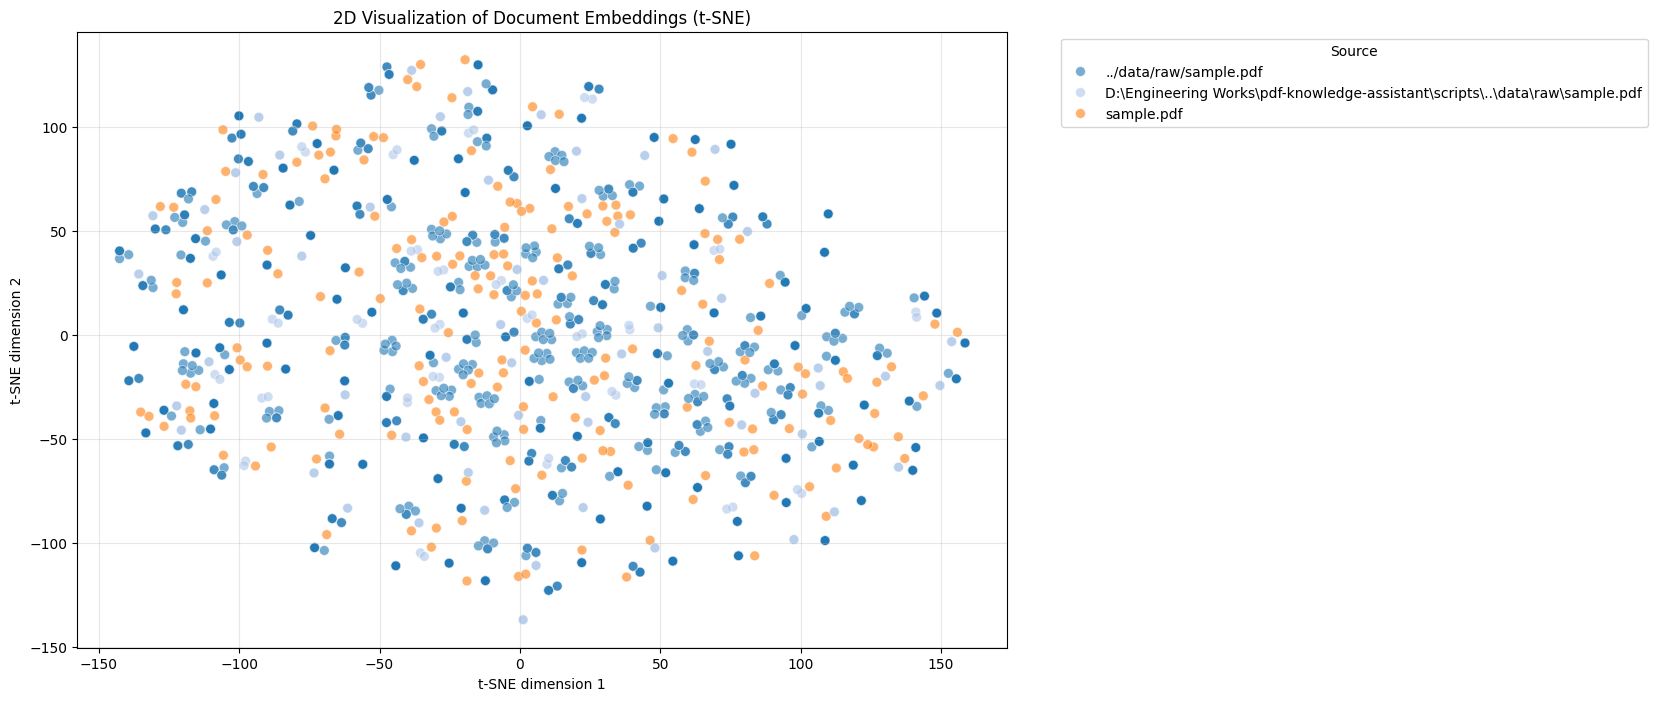

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE

# 1. Extract embeddings and metadata
data = retriever.vectorstore.get(include=['embeddings', 'metadatas'])
embeddings = np.array(data['embeddings'])
sources = [m.get('source', 'unknown') for m in data['metadatas']]

if len(embeddings) > 0:
    print(f"Applying t-SNE to {len(embeddings)} embeddings...")
    
    # 2. Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # 3. Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1], 
        hue=sources, 
        palette='tab20', 
        alpha=0.6,
        s=50,
        edgecolor='w',
        legend='full'
    )
    
    plt.title("2D Visualization of Document Embeddings (t-SNE)")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Source')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No embeddings found to visualize.")